# MMF1921 (Summer 2025) - Project 1
 
 The purpose of this program is to implement the following factor models
 
     a) Multi-factor OLS regression
     b) Fama-French 3-factor model
     c) LASSO
     d) Best Subset Selection
 
 and to use these factor models to estimate the asset expected returns and covariance matrix. 
 
These parameters will then be used to test the out-of-sample performance using MVO to construct optimal portfolios.
 
 Use can use this template to write your program.

     Student Name: Alex Khadra, Jerome Charbonneau, Katie Chai
     Student ID: 1005733976, 1012502025, 1005568066

In [1]:
!conda activate mmf1921


CommandNotFoundError: Your shell has not been properly configured to use 'conda activate'.
To initialize your shell, run

    $ conda init <SHELL_NAME>

Currently supported shells are:
  - bash
  - fish
  - tcsh
  - xonsh
  - zsh
  - powershell

See 'conda init --help' for more information and options.

IMPORTANT: You may need to close and restart your shell after running 'conda init'.




In [2]:
import time
import math
from scipy.stats import gmean
import matplotlib.pyplot as plt
from functions.BSS import *
from functions.FF import *
from functions.LASSO import *
from functions.MVO import *
from functions.OLS import *
import pandas as pd
import numpy as np

adjClose = pd.read_csv("MMF1921_AssetPrices.csv", index_col=0)
factorRet = pd.read_csv("MMF1921_FactorReturns.csv", index_col=0)

In [3]:
adjClose.index = pd.to_datetime(adjClose.index)
factorRet.index = pd.to_datetime(factorRet.index)

In [4]:
#rf and factor returns
riskFree = factorRet['RF']
factorRet = factorRet.loc[:,factorRet.columns != 'RF'];

In [5]:
#Identify the tickers and the dates
tickers = adjClose.columns
dates   = factorRet.index

In [6]:
# Calculate the stocks monthly excess returns
# pct change and drop the first null observation
returns = adjClose.pct_change(1).iloc[1:, :]

returns = returns.subtract(riskFree.values, axis=0)

# Align the price table to the asset and factor returns tables by discarding the first observation.
adjClose = adjClose.iloc[1:,:]

In [7]:
assert adjClose.index[0] == returns.index[0]
assert adjClose.index[0] == factorRet.index[0]

# 2. Define your initial parameters

In [8]:
#Initial budget to invest ($100,000)
initialVal = 100000

#Start of in-sample calibration period
calStart = pd.to_datetime('2008-01-01', format = '%Y-%m-%d')
calEnd   = calStart + pd.offsets.DateOffset(years=4) - pd.offsets.DateOffset(days=1)

#Start of out-of-sample test period
testStart = pd.to_datetime('2012-01-01', format = '%Y-%m-%d')
testEnd   = testStart + pd.offsets.DateOffset(years=1) - pd.offsets.DateOffset(days=1)

#Number of investment periods (each investment period is 1 year long)
NoPeriods = 5

#Factor models
#Note: You must populate the functions OLS.py, FF.py, LASSO.py and BSS.py with your own code.
FMList = [OLS, FF, LASSO, BSS]
NoModels = len(FMList)

#Tags for the portfolios under the different factor models
tags = ['OLS portfolio', 'FF portfolio', 'LASSO portfolio', 'BSS portfolio']

# 3. Construct and rebalance your portfolios

Here you will estimate your input parameters (exp. returns and cov. matrix etc) from the Fama-French factor models.
You will have to re-estimate your parameters at the start of each rebalance period, and then re-optimize and rebalance your portfolios accordingly.

Ensure you re-initialize the dates above if you run this cell repeatedly. 

In [9]:
# ── Reset dates before running the backtest ──
calStart = pd.to_datetime('2008-01-01', format='%Y-%m-%d')
calEnd   = calStart + pd.offsets.DateOffset(years=4) - pd.offsets.DateOffset(days=1)

testStart = pd.to_datetime('2012-01-01', format='%Y-%m-%d')
testEnd   = testStart + pd.offsets.DateOffset(years=1) - pd.offsets.DateOffset(days=1)

# ── λ tuning: run once on the first calibration window ──
lambda_grid = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
K = 4

tune_returns = returns[(pd.to_datetime('2008-01-01') <= returns.index) &
                       (returns.index <= pd.to_datetime('2011-12-31'))]

tune_factRet = factorRet[(pd.to_datetime('2008-01-01') <= factorRet.index) &
                         (factorRet.index <= pd.to_datetime('2011-12-31'))]

best_lambda, best_score = lambda_grid[0], np.inf

for lam in lambda_grid:
    _, _, B = LASSO(tune_returns, tune_factRet, lam, K, return_loadings=True)
    avg_nz = np.sum(np.abs(B) > 1e-4, axis=0).mean()
    print(f"lambda={lam:.4f} | avg non-zero coeffs: {avg_nz:.2f}")

    if abs(avg_nz - 3.5) < best_score:
        best_score = abs(avg_nz - 3.5)
        best_lambda = lam

print(f"\n→ Selected lambda: {best_lambda}")
lambda_ = best_lambda


# ── Main backtest loop ──
toDay = 0

currentVal = {i: np.zeros(NoPeriods) for i in range(NoModels)}
n = len(tickers)

x = {i: np.zeros([n, NoPeriods]) for i in range(NoModels)}

mu = {}
Q = {}
NoShares = {}

portfValue = {i: [] for i in range(NoModels)}

for t in range(NoPeriods):

    periodReturns = returns[(calStart <= returns.index) & (returns.index <= calEnd)]
    periodFactRet = factorRet[(calStart <= factorRet.index) & (factorRet.index <= calEnd)]

    current_price_idx = (calEnd - pd.offsets.DateOffset(days=7) <= adjClose.index) & \
                        (adjClose.index <= calEnd)
    currentPrices = adjClose[current_price_idx]

    periodPrices_idx = (testStart <= adjClose.index) & (adjClose.index <= testEnd)
    periodPrices = adjClose[periodPrices_idx]

    print("t =", t, "| calEnd =", calEnd, "| currentPrices length =", len(currentPrices))

    assert len(currentPrices) == 1

    currentPricesVec = currentPrices.iloc[0]

    if t == 0:
        for i in range(NoModels):
            currentVal[i][0] = initialVal
    else:
        for i in range(NoModels):
            currentVal[i][t] = (currentPricesVec @ NoShares[i].values.T).squeeze()

    fromDay = toDay
    toDay = toDay + len(periodPrices)

    for i in range(NoModels):
        mu[i], Q[i] = FMList[i](periodReturns, periodFactRet, lambda_, K)

    for i in range(NoModels):
        targetRet = gmean(periodFactRet.iloc[:, 0] + 1) - 1
        x[i][:, t] = MVO(mu[i], Q[i], targetRet)

    for i in range(NoModels):
        NoShares[i] = x[i][:, t] * currentVal[i][t] / currentPricesVec
        portfValue[i].append(periodPrices @ NoShares[i].values.T)

    calStart = calStart + pd.offsets.DateOffset(years=1)
    calEnd = calStart + pd.offsets.DateOffset(years=4) - pd.offsets.DateOffset(days=1)

    testStart = testStart + pd.offsets.DateOffset(years=1)
    testEnd = testStart + pd.offsets.DateOffset(years=1) - pd.offsets.DateOffset(days=1)


for i in range(NoModels):
    portfValue[i] = pd.concat(portfValue[i], axis=0)

portfValue = pd.DataFrame(
    [portfValue[i].values.squeeze() for i in range(NoModels)],
    index=tags,
    columns=portfValue[0].index
).T

lambda=0.0010 | avg non-zero coeffs: 8.60
lambda=0.0050 | avg non-zero coeffs: 7.35
lambda=0.0100 | avg non-zero coeffs: 6.30
lambda=0.0200 | avg non-zero coeffs: 4.80
lambda=0.0500 | avg non-zero coeffs: 3.05
lambda=0.1000 | avg non-zero coeffs: 2.15

→ Selected lambda: 0.05
t = 0 | calEnd = 2011-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 1 | calEnd = 2012-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 2 | calEnd = 2013-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 3 | calEnd = 2014-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS
t = 4 | calEnd = 2015-12-31 00:00:00 | currentPrices length = 1
USING EXHAUSTIVE SEARCH BSS


# 4. Results

In [10]:
# =============================================================================
# 4.1 IN-SAMPLE ANALYSIS — Adjusted R² for each factor model
# Evaluate any measures of fit of the regression models to assess their
# in-sample quality. You may want to modify Section 3 of this program to
# calculate the quality of fit each time the models are recalibrated.
# =============================================================================
# Adjusted R² penalizes models that use more factors, making it a fair
# comparison across OLS (8 factors), FF (3), LASSO (sparse), BSS (K=4).
#
# Formula: R²_adj = 1 - (1 - R²) * (T - 1) / (T - p - 1)
# where p = number of non-zero factor loadings (excluding intercept)
# =============================================================================

def adjusted_r2(returns, factRet, B):
    """
    Computes per-asset adjusted R² given a coefficient matrix B.

    Parameters
    ----------
    returns : (T, n) ndarray — excess asset returns
    factRet : (T, p) ndarray — factor returns (no intercept column)
    B       : (p+1, n) ndarray — fitted coefficients [alpha; beta]

    Returns
    -------
    adj_r2 : (n,) array — adjusted R² for each asset
    """
    T, n = returns.shape
    X    = np.column_stack([np.ones(T), factRet])   # (T, p+1)

    fitted    = X @ B                               # (T, n)
    residuals = returns - fitted                    # (T, n)

    # Total sum of squares (variance of actual returns)
    ss_tot = np.sum((returns - returns.mean(axis=0))**2, axis=0)   # (n,)

    # Residual sum of squares
    ss_res = np.sum(residuals**2, axis=0)                          # (n,)

    # R²
    r2 = 1 - ss_res / ss_tot                                       # (n,)

    # Number of non-zero factor loadings per asset (exclude intercept)
    p_eff = np.sum(np.abs(B[1:, :]) > 1e-8, axis=0).astype(float) # (n,)

    # Adjusted R² — guard against division by zero
    denom = T - p_eff - 1
    denom = np.where(denom <= 0, np.nan, denom)
    adj_r2 = 1 - (1 - r2) * (T - 1) / denom                       # (n,)

    return adj_r2


# ── Collect adjusted R² across all periods and models ────────────────────────
# We re-run each factor model on each calibration window and extract B.
# To do this cleanly we temporarily modify each function call to also
# return B. The simplest approach is to recompute B here directly.

model_names  = tags
adj_r2_store = {name: [] for name in model_names}   # period-averaged adj R²

# Calibration windows (same as backtest)
cal_starts = [pd.to_datetime(f'{y}-01-01') for y in [2008, 2009, 2010, 2011, 2012]]

for cal_start in cal_starts:
    cal_end = cal_start + pd.offsets.DateOffset(years=4) - pd.offsets.DateOffset(days=1)

    periodReturns = returns[(cal_start <= returns.index) & (returns.index <= cal_end)]
    periodFactRet = factorRet[(cal_start <= factorRet.index) & (factorRet.index <= cal_end)]

    R_arr = np.asarray(periodReturns, dtype=float)
    F_arr = np.asarray(periodFactRet, dtype=float)
    T, n  = R_arr.shape
    X_all = np.column_stack([np.ones(T), F_arr])                   # (T, 9)

    for idx, (model_fn, name) in enumerate(zip(FMList, model_names)):

        if 'OLS' in name:
            F_used = F_arr                                          # all 8 factors
            X_used = np.column_stack([np.ones(T), F_used])
            B = np.linalg.lstsq(X_used, R_arr, rcond=None)[0]     # (9, n)

        elif 'FF' in name:
            F_used = F_arr[:, :3]                                  # only Mkt, SMB, HML
            X_used = np.column_stack([np.ones(T), F_used])
            B = np.linalg.lstsq(X_used, R_arr, rcond=None)[0]     # (4, n)

        elif 'LASSO' in name:
            F_used = F_arr                                          # all 8 factors
            _, _, B = LASSO(periodReturns, periodFactRet,
                            lambda_, K, return_loadings=True)       # (9, n)

        elif 'BSS' in name:
            F_used = F_arr                                          # all 8 factors
            _, _, B = BSS(periodReturns, periodFactRet,
                        lambda_, K, return_loadings=True)         # (9, n)

        # Pass F_used not F_arr — adjusted_r2 gets exactly the factors B was fit on
        adj_r2 = adjusted_r2(R_arr, F_used, B)
        adj_r2_store[name].append(adj_r2.mean())

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── In-Sample Adjusted R² (averaged across assets) ──\n")
print(f"{'Period':<20}", end="")
for name in model_names:
    short = name.replace(' portfolio', '')
    print(f"{short:>10}", end="")
print()

years = [2008, 2009, 2010, 2011, 2012]
for k, yr in enumerate(years):
    print(f"{str(yr)+'-'+str(yr+3):<20}", end="")
    for name in model_names:
        print(f"{adj_r2_store[name][k]:>10.4f}", end="")
    print()

print(f"\n{'Mean':<20}", end="")
for name in model_names:
    print(f"{np.mean(adj_r2_store[name]):>10.4f}", end="")
print()


# =============================================================================
# 4.2 OUT-OF-SAMPLE ANALYSIS — Return, volatility, Sharpe ratio
# Calculate the portfolio average return, variance (or standard 
# deviation), and any other performance and/or risk metric you wish to 
# include in your report.
# =============================================================================
# portfValue is a (T_oos, NoModels) DataFrame with daily/monthly portfolio values.
# We compute monthly returns from it and derive performance metrics.
# =============================================================================

# ── Monthly returns from portfolio value series ───────────────────────────────
portf_returns = portfValue.pct_change(1).dropna()                  # (T-1, NoModels)

# ── Risk-free rate aligned to out-of-sample period (2012-2016) ───────────────
rf_oos = riskFree[(pd.to_datetime('2012-01-01') <= riskFree.index) &
                  (riskFree.index <= pd.to_datetime('2016-12-31'))]

# portfValue may be at daily frequency; if so resample to monthly for metrics
# If already monthly, skip the resample
if len(portf_returns) > 60:   # more than 60 obs → likely daily
    portf_monthly = portfValue.resample('ME').last().pct_change(1).dropna()
else:
    portf_monthly = portf_returns

# Align rf to portf_monthly index
rf_aligned = rf_oos.reindex(portf_monthly.index, method='nearest').ffill()

# ── Metrics ───────────────────────────────────────────────────────────────────
avg_return = portf_monthly.mean() * 12             # annualized
volatility = portf_monthly.std()  * np.sqrt(12)    # annualized
avg_rf     = rf_aligned.mean()    * 12             # annualized risk-free

sharpe     = (avg_return - avg_rf) / volatility

total_return = (portfValue.iloc[-1] / portfValue.iloc[0] - 1)

# ── Print summary ─────────────────────────────────────────────────────────────
print("\n── Out-of-Sample Performance (2012–2016) ──\n")
print(f"{'Metric':<25}", end="")
for name in model_names:
    short = name.replace(' portfolio', '')
    print(f"{short:>12}", end="")
print()

metrics = {
    'Avg Annual Return'  : avg_return,
    'Annual Volatility'  : volatility,
    'Sharpe Ratio'       : sharpe,
    'Total Return'   : total_return,
}

for metric_name, vals in metrics.items():
    print(f"{metric_name:<25}", end="")
    for name in model_names:
        print(f"{vals[name]:>12.4f}", end="")
    print()

USING EXHAUSTIVE SEARCH BSS
USING EXHAUSTIVE SEARCH BSS
USING EXHAUSTIVE SEARCH BSS
USING EXHAUSTIVE SEARCH BSS
USING EXHAUSTIVE SEARCH BSS

── In-Sample Adjusted R² (averaged across assets) ──

Period                     OLS        FF     LASSO       BSS
2008-2011               0.4797    0.4358    0.3998    0.4996
2009-2012               0.4767    0.3984    0.3373    0.4811
2010-2013               0.4364    0.3473    0.2603    0.4530
2011-2014               0.3974    0.2800    0.1854    0.4298
2012-2015               0.4393    0.3411    0.1982    0.4666

Mean                    0.4459    0.3605    0.2762    0.4660

── Out-of-Sample Performance (2012–2016) ──

Metric                            OLS          FF       LASSO         BSS
Avg Annual Return              0.0854      0.0855      0.0853      0.0704
Annual Volatility              0.0909      0.0911      0.0925      0.0915
Sharpe Ratio                   0.9323      0.9324      0.9160      0.7626
Total Return                   0.48

<Figure size 640x480 with 0 Axes>

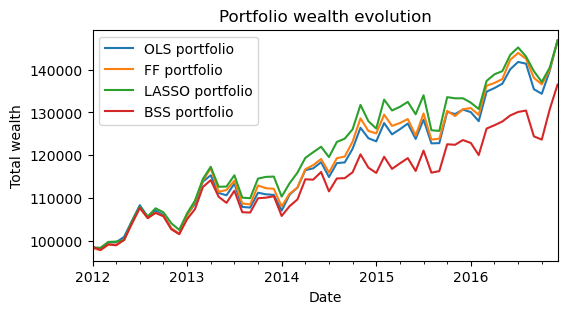

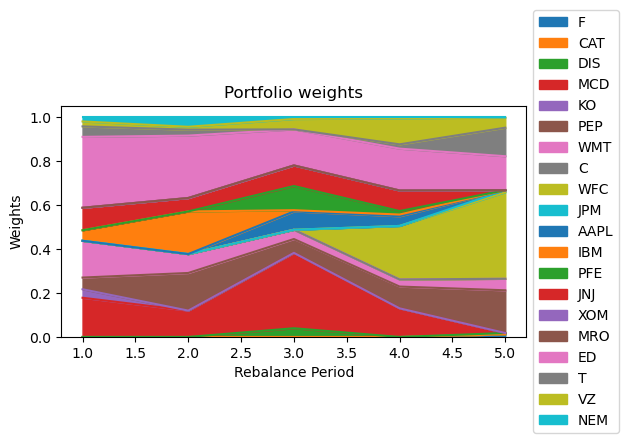

In [11]:
#--------------------------------------------------------------------------
# 4.3 Plot the portfolio wealth evolution 
# 
# Note: The code below plots all portfolios onto a single plot. However,
# you may want to split this into multiple plots for clarity, or to
# compare a subset of the portfolios. 
#--------------------------------------------------------------------------
# Calculate the dates of the out-of-sample period

fig = plt.figure(1)
portfValue.plot(title = 'Portfolio wealth evolution',
                ylabel = 'Total wealth',
                figsize = (6, 3),
                legend = True)
plt.savefig("images/wealth.svg")

#--------------------------------------------------------------------------
# 4.4 Plot the portfolio weights period-over-period
#--------------------------------------------------------------------------
# OLS Portfolio weights

fig2 = plt.figure(2)
x[0][x[0] < 0] = 0
weights = pd.DataFrame(x[0][(x[0] >0).any(axis=1)], index = tickers[(x[0] >0).any(axis=1)])
weights.columns = [col + 1 for col in weights.columns]
weights.T.plot.area(title = 'Portfolio weights',
                  ylabel = 'Weights', xlabel = 'Rebalance Period',
                  figsize = (6, 3),
                  legend = True, stacked = True)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.savefig("images/weights.svg")
#
# ###########################################################################
# # Program End